In [1]:
import sys
import os
sys.path.append('../')
sys.path.append("../../")

import numpy as np
import matplotlib.pyplot as plt
import os
from pydicom import dcmread

from types import MappingProxyType
import torch

from DoseEngines import ModelConfig
from DoseEngines import DoseEngine

/home/bolo/anaconda3/envs/autoplan/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
config = ModelConfig(ct_array_shape=(100, 100, 100), resolution=(0.2, 0.2, 0.2), field_size=(10, 10), number_of_leaf_pairs=60, tpr_20_10=0.72, number_of_cps=1, iso_center=(0.0, 0.0, 0.0), mean_photon_energy_MeV=41.77363204956055, downsampling_factor=(2,2,2))
device = config.device
print(config)

preset=None ct_array_shape=(50, 50, 50) resolution=(0.4, 0.4, 0.4) field_size=(10, 10) downsampling_factor=(2, 2, 2) iso_center=(0.0, 0.0, 0.0) minimum_leaf_overlap=0.5 maximum_leaf_speed=2.25 minimum_gantry_angle_speed=0.1 maximum_gantry_angle_speed=6.0 maximum_gantry_angle_speed_variation=0.75 minimum_dose_rate=50.0 maximum_dose_rate=600.0 is_fff=True mu_scaling=18.78 focal_spot_sigma=0.15 focus_to_collimator=49.7 oar_coeffs=(1.0, -0.0001, 2.5e-07) mlc_thickness=6.8 mlc_mu=0.7 dtype=torch.float32 device=device(type='cuda') number_of_leaf_pairs=60 tpr_20_10=0.72 mean_photon_energy_MeV=41.77363204956055 SID=100.0 number_of_cps=1 starting_angle=0.0


In [3]:
x_ct = 0.0 * np.expand_dims(np.ones(np.multiply(config.ct_array_shape, config.downsampling_factor)), 0)
y_mlc = np.zeros((1, 2, config.number_of_cps, config.number_of_leaf_pairs))
y_mlc[:, 0, :, :] = 0.5
y_mlc[:, 1, :, :] = 1.0
mus = 1.3 * np.ones((1, config.number_of_cps), dtype=np.float32)
dose_layer = DoseEngine(config, 99)
dose = dose_layer(torch.tensor(y_mlc, dtype=torch.float32, device=device), torch.tensor(mus, dtype=torch.float32, device=device), ct_image=torch.tensor(x_ct, dtype=torch.float32, device=device))

torch.Size([1, 100, 100, 100])


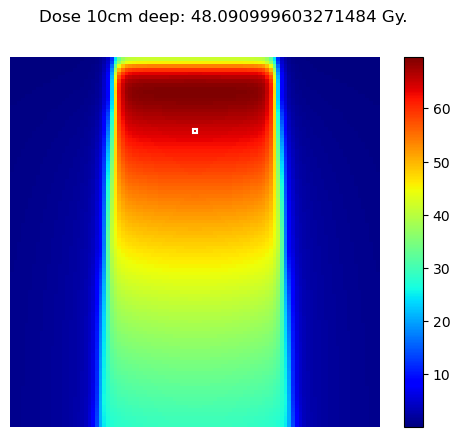

Recommended mean avg. 0.8686365485191345


In [4]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np  # Assuming numpy is already imported
# Assuming 'dose' is a 4D array: [batch, depth, height, width]

slice_idx = 84
print(dose.shape)

fig, ax = plt.subplots()
im = ax.imshow(dose[0, :, :, 50].cpu().detach().numpy(), cmap='jet', vmin=np.min(dose.cpu().detach().numpy()), vmax=np.max(dose.cpu().detach().numpy()), interpolation='nearest')


plt.suptitle(f"Dose 10cm deep: {np.round(dose[0, 50, 50, 50].detach().cpu().numpy(), 3)} Gy.")
# Add a rectangle around [25, 64]
rect = patches.Rectangle((50 - 1, 20 - 1), 1, 1, linewidth=1.5, edgecolor='white', facecolor='none')
ax.add_patch(rect)

ax.axis('off')
plt.colorbar(im, ax=ax)
plt.show()
print(f"Recommended mean avg. {config.mean_photon_energy_MeV / dose[0, 50, 50, 50]}")